In [32]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind
from natsort import natsorted
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import glob
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from scipy.stats import pearsonr
import os
from scipy.stats import linregress
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import nibabel as nib
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
import sys
import seaborn as sns
from nibabel import cifti2
from scipy.spatial import procrustes
from scipy.stats import ttest_ind
np.random.seed(42)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
blind_task_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_rh_Schaefer2Wang_judgement.npy')
blind_task_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_lh_Schaefer2Wang_judgement.npy')
control_task_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_rh_Schaefer2Wang_judgement.npy')
control_task_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_lh_Schaefer2Wang_judgement.npy')

In [34]:
blind_rest_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_rh_Schaefer2Wang.npy')
blind_rest_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_lh_Schaefer2Wang.npy')
control_rest_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_rh_Schaefer2Wang.npy')
control_rest_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_lh_Schaefer2Wang.npy')

In [35]:
regions = [x.split(' - ')[1] for x in pd.read_csv('/mnt/DataDrive3/NishioM/Blind/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values] + [x.split(' - ')[1] for x in pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values]

In [36]:
region_label = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 9, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 7, 9, 7, 9, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 8, 8,
       8, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 9, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 9, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 9, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9,
       7, 9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 9, 8, 8, 8,
       8, 8, 8, 8]

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'TempPar', 'Auditory']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

In [37]:
roi_list = ['V1v',
 'V1d',
 'V2v',
 'V2d',
 'V3v',
 'V3d',
 'hV4',
 'VO1',
 'VO2',
 'PHC1',
 'PHC2',
 'MST',
 'hMT',
 'LO2',
 'LO1',
 'V3b',
 'V3a',
 'IPS0',
 'IPS1',
 'IPS2',
 'IPS3',
 'IPS4',
 'IPS5',
 'SPL1',
 'FEF']
domain_groups = {
    'visual': ['V1v',
 'V1d',
 'V2v',
 'V2d',
 'V3v',
 'V3d',
 'hV4',
 'VO1',
 'VO2',
 'PHC1',
 'PHC2',
 'MST',
 'hMT',
 'LO2',
 'LO1',
 'V3b',
 'V3a',
 'IPS0',
 'IPS1',
 'IPS2',
 'IPS3',
 'IPS4',
 'IPS5',
 'SPL1',
 'FEF']
}
#, 'V7', 'V8','V3CD', 'FEF', 'PEF', 'POS1', 'POS2', 'VVC', 'FFC', 'VMV1-3',

In [38]:
SA = pd.read_csv('../Dataset/Sensorimotor_Association_Axis_AverageRanks.csv')

In [39]:
rows = []
with open("../Derivatives/all_schaefer_overlaps.txt", "r") as f:
    for line in f:
        parts = line.strip().split(":")
        if len(parts) > 1:
            numbers = [int(num) for num in parts[1].strip().split() if num]
            rows.append(np.mean([SA['finalrank.hemisphere'][i-1] for i in numbers if i!=0])) #SA['finalrank.hemisphere']
df_auditory = pd.DataFrame(rows)
rows = []
with open("../Derivatives/wang_schaefer_overlaps.txt", "r") as f:
    for line in f:
        parts = line.strip().split(":")
        if len(parts) > 1:
            numbers = [int(num) for num in parts[1].strip().split() if num]
            rows.append(np.mean([SA['finalrank.hemisphere'][i-1] for i in numbers if i!=0]))
df_visual = pd.DataFrame(rows)

In [40]:
df_visual['region'] = regions
df_visual.groupby('region').mean().reset_index().sort_values(0).region.values

array(['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'V3a', 'hV4', 'VO1',
       'VO2', 'PHC1', 'IPS0', 'LO1', 'V3b', 'IPS1', 'SPL1', 'PHC2', 'hMT',
       'MST', 'IPS2', 'IPS3', 'LO2', 'IPS4', 'IPS5', 'FEF'], dtype=object)

In [41]:
def compute_roi_connectivity(data, region_label, MMPname, roi_name):
    subject_data = []
    roi_cols = [i for i, name in enumerate(MMPname) if roi_name in name]
    
    for subj in data:
        z_corr = np.tanh(subj)  # Fisher z
        df = pd.DataFrame(z_corr).T
        df.index = region_label[200:]
        df.columns = MMPname
        
        roi_df = df.iloc[:, roi_cols]
        avg_conn = roi_df.mean(axis=1).values  # mean across ROI columns for each region
        subject_data.append(avg_conn)

    return pd.DataFrame(subject_data, columns=region_label[200:])

In [42]:
task_dfs = {}
for roi in regions[:25]:
    # Extract and average for each group
    blind_df = compute_roi_connectivity(blind_task_rh, region_label, regions[:25], roi)
    control_df = compute_roi_connectivity(control_task_rh, region_label, regions[:25], roi)
    blind_df['ID'] = ['eb'+str(i) for i in np.arange(blind_df.shape[0])]
    control_df['ID'] = ['sc'+str(i) for i in np.arange(control_df.shape[0])]
    
    # Add group labels
    blind_df['group'] = 'blind'
    blind_df['condition'] = 'task'
    control_df['group'] = 'control'
    control_df['condition'] = 'task'
    
    # Combine groups
    full_df = pd.concat([blind_df, control_df], ignore_index=True)
    
    # Save
    task_dfs[roi] = full_df

In [43]:
rest_dfs = {}
for roi in regions[:25]:
    # Extract and average for each group
    blind_df = compute_roi_connectivity(blind_rest_rh, region_label, regions[:25], roi)
    control_df = compute_roi_connectivity(control_rest_rh, region_label, regions[:25], roi)
    blind_df['ID'] = ['eb'+str(i) for i in np.arange(blind_df.shape[0])]
    control_df['ID'] = ['sc'+str(i) for i in np.arange(control_df.shape[0])]
    
    # Add group labels
    blind_df['group'] = 'blind'
    blind_df['condition'] = 'rest'
    control_df['group'] = 'control'
    control_df['condition'] = 'rest'
    
    # Combine groups
    full_df = pd.concat([blind_df, control_df], ignore_index=True)
    
    # Save
    rest_dfs[roi] = full_df        

In [44]:
normalized_task = {}
for roi, df in task_dfs.items():
    features = df.drop(columns=['group', 'ID', 'condition'])
    norm_df = features.T.groupby(features.columns).mean().T
    #norm_df = norm_df.div(features.mean(axis=1), axis=0)  # normalize by subject mean
    norm_df.columns = network_names
    norm_df['group'] = df['group'].values
    norm_df['ID'] = df['ID'].values
    norm_df['condition'] = df['condition'].values
    normalized_task[roi] = norm_df

In [45]:
normalized_rest = {}
for roi, df in rest_dfs.items():
    features = df.drop(columns=['group', 'ID', 'condition'])
    norm_df = features.T.groupby(features.columns).mean().T
    #norm_df = norm_df.div(features.mean(axis=1), axis=0)  # normalize by subject mean
    norm_df.columns = network_names
    norm_df['group'] = df['group'].values
    norm_df['ID'] = df['ID'].values
    norm_df['condition'] = df['condition'].values
    normalized_rest[roi] = norm_df

In [46]:
long_data = []
for roi, df in normalized_task.items():
    df_copy = df.copy()
    df_copy['ROI'] = roi
    long_data.append(df_copy)
for roi, df in normalized_rest.items():
    df_copy = df.copy()
    df_copy['ROI'] = roi
    long_data.append(df_copy)

In [47]:
combined_df = pd.concat(long_data, ignore_index=True)
df_long = combined_df.melt(id_vars=['group','ID', 'ROI', 'condition'], var_name='network', value_name='value')

In [48]:
streams = {
    'Primary': ['V1v','V1d','V2v','V2d','V3v','V3d','hV4','VO1','VO2','PHC2','PHC1','LO1','LO2','hMT','MST','V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1'],#['V1v','V1d','V2v','V2d','V3v','V3d','hV4'],
    'Ventral': ['VO1','VO2','PHC2','PHC1'], #
    'Lateral': ['LO1','LO2','hMT','MST'],
    'Dorsal': ['V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1'],
}#'All': ['V1v','V1d','V2v','V2d','V3v','V3d','hV4','VO1','VO2','PHC2','PHC1','LO1','LO2','hMT','MST','V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1']
stream_order = ['Primary', 'Dorsal', 'Lateral', 'Ventral']
roi_to_stream = {roi: stream for stream, rois in streams.items() for roi in rois}
df_long['stream'] = df_long['ROI'].map(roi_to_stream)
df_long = df_long.dropna()

In [49]:
df_long = df_long.loc[:, ['group', 'ID', 'condition', 'network', 'stream', 'value']].groupby(['group', 'ID', 'condition', 'network', 'stream']).mean().reset_index()

In [50]:
df_long = df_long[df_long['network'] == 'Cont']
df_long = df_long[df_long['stream'] == 'Primary']

In [51]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Convert to categorical
df_long['group'] = df_long['group'].astype('category')
df_long['condition'] = df_long['condition'].astype('category')
df_long['stream'] = df_long['stream'].astype('category')

# Full three-way ANOVA
model = ols('value ~ C(group)*C(condition) + C(ID)', data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)



                         sum_sq    df          F        PR(>F)
C(group)               0.049247   1.0  32.444188  2.621910e-06
C(condition)           0.005502   1.0   3.624744  6.595211e-02
C(ID)                  0.382513  33.0   7.636444  5.096202e-08
C(group):C(condition)  0.021605   1.0  14.233688  6.601455e-04
Residual               0.048573  32.0        NaN           NaN


/tmp/ipykernel_1581358/1595545821.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = df_long.groupby(['stream','group','condition'])['value'].agg(['mean','sem']).reset_index()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


blind -2.788287133910807 0.009501185303888509
control 0.8027391602910967 0.42765520404567137


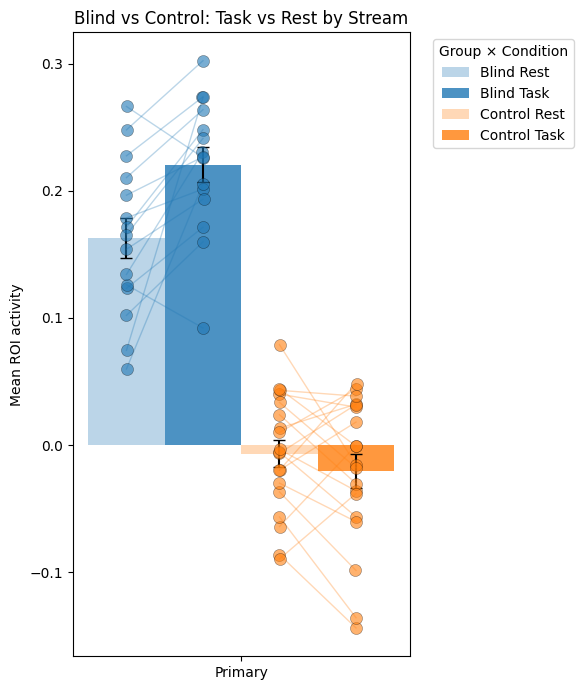

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Compute mean and SEM per group × condition × stream
plot_df = df_long.groupby(['stream','group','condition'])['value'].agg(['mean','sem']).reset_index()
plot_df.rename(columns={'mean':'Mean','sem':'SEM'}, inplace=True)

plt.figure(figsize=(6,7)) #1.5

streams = plot_df['stream'].unique()
n_streams = len(streams)
bar_width = 0.2
x = np.arange(n_streams)

# Bar parameters
shift = [-1.5*bar_width, -0.5*bar_width, 0.5*bar_width, 1.5*bar_width]
colors = ['#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e']
alphas = [0.3, 0.8, 0.3, 0.8]
labels = ['Blind Rest', 'Blind Task', 'Control Rest', 'Control Task']

# Draw bars
for i, (group, condition) in enumerate([('blind','rest'),
                                        ('blind','task'),
                                        ('control','rest'),
                                        ('control','task')]):
    vals = plot_df[(plot_df['group']==group) & (plot_df['condition']==condition)].set_index('stream')['Mean']
    sems = plot_df[(plot_df['group']==group) & (plot_df['condition']==condition)].set_index('stream')['SEM']
    plt.bar(x + shift[i], vals[streams], yerr=sems[streams],
            width=bar_width, color=colors[i], alpha=alphas[i],
            capsize=4, label=labels[i])

# Add significance stars + t-values
y_offset = 0.05  # space above bar

stream = streams[0]
for group in ['blind', 'control']:
    rest_vals = df_long[(df_long['group']==group) & 
                            (df_long['condition']=='rest') &
                            (df_long['stream']==stream)]['value']
    task_vals  = df_long[(df_long['group']==group) & 
                            (df_long['condition']=='task') &
                            (df_long['stream']==stream)]['value']
    t, p = ttest_ind(rest_vals, task_vals, equal_var=False)
    print(group, t, p)


# Connect same subject points with lines
for j, stream in enumerate(streams):
    for group in ['blind', 'control']:
        for sub in df_long['ID'].unique():
            
            sub_df = df_long[(df_long['ID']==sub) &
                             (df_long['group']==group) &
                             (df_long['stream']==stream)]
            
            # Need both rest and task to connect
            if set(sub_df['condition']) == {'rest','task'}:
                
                # Get values
                rest_val = sub_df[sub_df['condition']=='rest']['value'].values[0]
                task_val = sub_df[sub_df['condition']=='task']['value'].values[0]
                
                # X positions
                if group == 'blind':
                    x_rest = x[j] + shift[0]
                    x_task = x[j] + shift[1]
                    color = '#1f77b4'
                else:
                    x_rest = x[j] + shift[2]
                    x_task = x[j] + shift[3]
                    color = '#ff7f0e'
                
                # Draw line
                plt.plot([x_rest, x_task],
                         [rest_val, task_val],
                         color=color,
                         alpha=0.3,
                         linewidth=1,
                         zorder=2)

jitter_scale = 0.001 # controls horizontal spread

for i, (group, condition) in enumerate([('blind','rest'),
                                        ('blind','task'),
                                        ('control','rest'),
                                        ('control','task')]):
    for j, stream in enumerate(streams):
        vals = df_long[(df_long['group']==group) &
                       (df_long['condition']==condition) &
                       (df_long['stream']==stream)]['value']
        
        # x position with jitter
        x_scatter = (x[j] + shift[i] +
                     np.random.normal(0, jitter_scale, size=len(vals)))
        
        plt.scatter(x_scatter, vals,
                    color=colors[i],
                    alpha=0.6,
                    s=75,
                    edgecolor='black',
                    linewidth=0.3,
                    zorder=3)

plt.xticks(x, streams)
#plt.ylim([-0.1, 0.35])
plt.ylabel('Mean ROI activity')
plt.title('Blind vs Control: Task vs Rest by Stream')

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Group × Condition')
plt.tight_layout()


In [53]:
blind_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_rh_Wang2YeoThalamus.npy') #_judgement.npy')
blind_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_lh_Wang2YeoThalamus.npy') #_judgement.npy')
control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_rh_Wang2YeoThalamus.npy') #_judgement.npy')
control_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_lh_Wang2YeoThalamus.npy') #_judgement.npy')

In [54]:
blind_MMP_rh_task = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_rh_Wang2YeoThalamus_judgement.npy')
blind_MMP_lh_task = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_lh_Wang2YeoThalamus_judgement.npy')
control_MMP_rh_task = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_rh_Wang2YeoThalamus_judgement.npy')
control_MMP_lh_task = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_lh_Wang2YeoThalamus_judgement.npy')

In [55]:
region_label = [
   1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
   1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
   2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
   3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
   4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
   5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
   6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
   7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
   7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
   7, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
   1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
   2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,
   3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4,
   4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
   5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
   6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7,
   7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
   7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
   7, 7, 7, 7
]

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

In [56]:
labels, ctab, names = nib.freesurfer.read_annot('/mnt/DataDrive3/NishioM/Blind/template/rh.HCPMMP1.annot')
roi_names = [name.decode('utf-8') for name in names]
MMPname = roi_names[1:]

In [58]:
nucleis = np.load('../Dataset/blind/yeo_thalamus_left_labels_Italy.npy')
nucleilabel = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
wanglabel = pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t')
wanglabel = [x.split('- ')[1] for x in wanglabel.index.values]

In [59]:
cb = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_blind_subjects', header=None)[0].values
sc = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_control_subjects', header=None)[0].values

In [60]:
blind_V1 = []
blind_A1 = []
for i in np.arange(blind_MMP_lh.shape[0]):
    corr_matrix = blind_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = wanglabel
    #V1_cols = [idx for idx, label in enumerate(wanglabel) if label in ['V1v','V1d','V2v','V2d','V3v','V3d','hV4','VO1','VO2','PHC2','PHC1','LO1','LO2','hMT','MST','V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1']]
    V1_cols = [idx for idx, label in enumerate(wanglabel) if label not in ['IPS0','IPS1','IPS2','IPS3','IPS4', 'IPS5', 'SPL1', 'FEF']]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    blind_V1.append(avg_visual)

In [61]:
control_V1 = []
for i in np.arange(control_MMP_lh.shape[0]):
    corr_matrix = control_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = wanglabel
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    control_V1.append(avg_visual)

In [62]:
df_V1 = pd.concat([pd.DataFrame(blind_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1.columns = nucleis
df_V1['group'] = list(np.repeat('blind', len(blind_V1))) +  list(np.repeat('control', len(control_V1)))

In [63]:
features = df_V1.iloc[:, :-1]
group = df_V1['group']
df_V1_network = features.T.groupby(features.columns).mean().T
df_V1_network.columns = nucleilabel 
df_V1_network['group'] = group

In [64]:
df_V1_network['condition'] = 'rest'
df_V1_network['subject'] = list(cb) + list(sc)

In [65]:
blind_V1 = []
blind_A1 = []
for i in np.arange(blind_MMP_lh_task.shape[0]):
    corr_matrix = blind_MMP_lh_task[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = wanglabel
    #V1_cols = [idx for idx, label in enumerate(wanglabel) if label in ['V1v','V1d','V2v','V2d','V3v','V3d','hV4','VO1','VO2','PHC2','PHC1','LO1','LO2','hMT','MST','V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1']]
    V1_cols = [idx for idx, label in enumerate(wanglabel) if label not in ['IPS0','IPS1','IPS2','IPS3','IPS4', 'IPS5', 'SPL1', 'FEF']]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    blind_V1.append(avg_visual)

In [66]:
control_V1 = []
for i in np.arange(control_MMP_lh_task.shape[0]):
    corr_matrix = control_MMP_lh_task[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = wanglabel
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    control_V1.append(avg_visual)

In [67]:
df_V1_task = pd.concat([pd.DataFrame(blind_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1_task.columns = nucleis
df_V1_task['group'] = list(np.repeat('blind', len(blind_V1))) +  list(np.repeat('control', len(control_V1)))

In [68]:
features = df_V1_task.iloc[:, :-1]
group = df_V1_task['group']
df_V1_network_task = features.T.groupby(features.columns).mean().T
df_V1_network_task.columns = nucleilabel 
df_V1_network_task['group'] = group

In [69]:
df_V1_network_task['condition'] = 'task'
df_V1_network_task['subject'] = list(cb) + list(sc)

In [70]:
df_V1_network = pd.concat([df_V1_network, df_V1_network_task], axis=0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


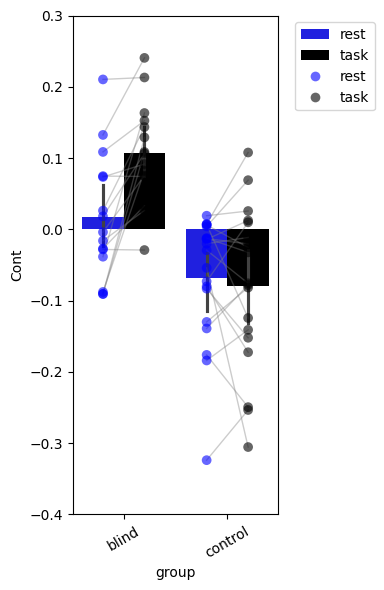

In [ ]:
for region in [df_V1_network]: #, df_A1_network]:
    # Melt into long format for seaborn
    df_long = region
    # Initialize plot
    plt.figure(figsize=(4,6))
    sns.barplot(x='group', y='Cont', hue='condition', data=df_long, palette=['blue', 'black'])
    sns.stripplot(x='group', y='Cont', hue='condition', data=df_long,
                dodge=True, jitter=False, marker='o', s=7, alpha=0.6, palette=['blue', 'black'])
    for (g, s), d in df_long.groupby(['group', 'subject']):
        if d['condition'].nunique() == 2:
            d_sorted = d.sort_values('condition')  # ensure order (rest → task)

            x_positions = []
            for cond in d_sorted['condition']:
                # match seaborn dodge manually
                base = list(df_long['group'].unique()).index(g)
                offset = -0.2 if cond == d_sorted['condition'].unique()[0] else 0.2
                x_positions.append(base + offset)

            plt.plot(x_positions, d_sorted['Cont'].values,
                    color='gray', alpha=0.4, linewidth=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim([-0.4, 0.3])
    plt.xticks(rotation=30)
    plt.tight_layout()